In [1]:
import tensorflow as tf
print(tf.__version__)


/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2.20.0


In [2]:
from tf_keras_vis.utils.scores import CategoricalScore
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/cats-vs-dogs-classifier-tensorflow2-fine-tuned-mobilenetv2-v1/mobilenetv2_catsdogs.keras")
model.summary()

print("Model yüklendi ve hazır.")

def load_preprocess_image(img_path, target_size=(224,224)):
    # OpenCV ile yükle ve RGB formatına çevir
    img = cv2.imread(img_path)[..., ::-1]
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalize et
    #img = np.expand_dims(img, axis=0)  # (1, H, W, C)
    return img

img_path = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/dogs/dog_415.jpg"
img_batch = load_preprocess_image(img_path)

# from tf_explain.core.integrated_gradients import IntegratedGradients

# explainer = IntegratedGradients()

# grid = explainer.explain(
#     (img_batch, None),   # input
#     model,               # model
#     class_index=0
# )

# plt.imshow(grid)
# plt.axis("off")




Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314,629 (20.27 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,055,364 (11.66 MB)

Model yüklendi ve hazır.


In [3]:
import numpy as np


def create_patch_masks(img, patch_size=(28, 28)):
    H, W = img.shape[1], img.shape[2]
    ph, pw = patch_size
    h_patches = H // ph
    w_patches = W // pw
    
    masks = []
    for i in range(h_patches):
        for j in range(w_patches):
            mask = np.ones_like(img)
            mask[:, i*ph:(i+1)*ph, j*pw:(j+1)*pw, :] = 0
            masks.append(mask)
    return np.array(masks), h_patches, w_patches


# def patch_integrated_gradients(model, img, class_idx, patch_size=(28, 28)):
#     explainer = IntegratedGradients()
    
#     masks, h_p, w_p = create_patch_masks(img, patch_size) # maskeleri oluştur
#     patch_scores = []
    
#     for mask in masks:
#         masked_img = img * mask
#         grid = explainer.explain((masked_img, None), model, class_index=class_idx)
#         patch_scores.append(np.sum(grid))  # IG toplam etkisi
        
#     patch_scores = np.array(patch_scores).reshape(h_p, w_p)
#     return patch_scores



In [14]:
import numpy as np
import tensorflow as tf
import cv2

def patch_integrated_gradients(model, img, patch_size=(28, 28), steps=30, mode="cat"):
    # Model dog probability verir: p_dog = model(img)
    # Cat probability = 1 - p_dog

    H, W, _ = img.shape
    ph, pw = patch_size

    h_patches = H // ph
    w_patches = W // pw

    patch_scores = np.zeros((h_patches, w_patches))

    for i in range(h_patches):
        for j in range(w_patches):
            # Patch mask oluştur
            mask = np.ones_like(img)
            mask[i*ph:(i+1)*ph, j*pw:(j+1)*pw, :] = 0.0

            # IG accumulation
            total_grad = 0.0

            for k in range(steps):
                alpha = k / steps
                x = img * (1 - alpha * (1 - mask))
                x = tf.expand_dims(x, 0)

                with tf.GradientTape() as tape:
                    tape.watch(x)
                    p_dog = model(x, training=False)
                    p_dog = tf.squeeze(p_dog)

                    if mode == "dog":
                        target = p_dog
                    else:
                        target = 1 - p_dog   # CAT

                grads = tape.gradient(target, x)
                total_grad += grads.numpy().sum()

            patch_scores[i, j] = total_grad
            print(f"Processed patch ({i+1}, {j+1})")
        print(f"Processed row {i+1}/{h_patches}")
    return patch_scores

def visualize_patch_map(img, patch_map, patch_size=(28, 28), alpha=0.45):
    # Patch score → 224×224'e upscale
    heatmap = cv2.resize(patch_map, (224, 224), interpolation=cv2.INTER_NEAREST)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)

    img_resized = (cv2.resize(img, (224, 224))*255).astype(np.uint8)

    overlay = cv2.addWeighted(img_resized, 1 - alpha, heatmap, alpha, 0)
    return overlay



Processed patch (1, 1)
Processed patch (1, 2)
Processed patch (1, 3)
Processed patch (1, 4)
Processed patch (1, 5)
Processed patch (1, 6)
Processed patch (1, 7)
Processed patch (1, 8)
Processed row 1/8
Processed patch (2, 1)
Processed patch (2, 2)
Processed patch (2, 3)
Processed patch (2, 4)
Processed patch (2, 5)
Processed patch (2, 6)
Processed patch (2, 7)
Processed patch (2, 8)
Processed row 2/8
Processed patch (3, 1)
Processed patch (3, 2)
Processed patch (3, 3)
Processed patch (3, 4)
Processed patch (3, 5)
Processed patch (3, 6)
Processed patch (3, 7)
Processed patch (3, 8)
Processed row 3/8
Processed patch (4, 1)
Processed patch (4, 2)
Processed patch (4, 3)
Processed patch (4, 4)
Processed patch (4, 5)
Processed patch (4, 6)
Processed patch (4, 7)
Processed patch (4, 8)
Processed row 4/8
Processed patch (5, 1)
Processed patch (5, 2)
Processed patch (5, 3)
Processed patch (5, 4)
Processed patch (5, 5)
Processed patch (5, 6)
Processed patch (5, 7)
Processed patch (5, 8)
Processe

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

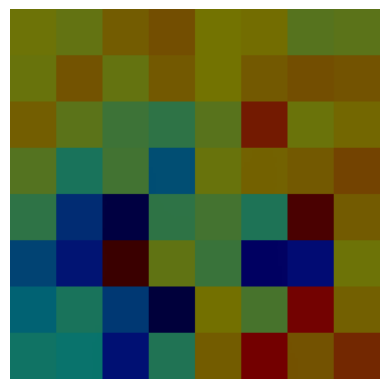

In [ ]:
img = load_preprocess_image("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/cats/cat_446.jpg")


patch_map = patch_integrated_gradients(
    model,
    img,
    patch_size=(28,28),
    steps=30,
    mode="cat"  
)



(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

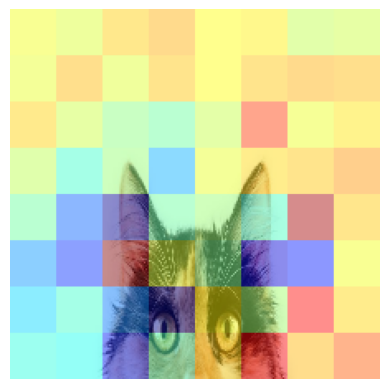

In [15]:
overlay = visualize_patch_map(img, patch_map, patch_size=(28, 28))
plt.imshow(overlay)
plt.axis("off")


In [17]:
img2 = load_preprocess_image("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/dogs/dog_142.jpg")


patch_map = patch_integrated_gradients(
    model,
    img2,
    patch_size=(28,28),
    steps=30,
    mode="dog"  
)

Processed patch (1, 1)
Processed patch (1, 2)
Processed patch (1, 3)
Processed patch (1, 4)
Processed patch (1, 5)
Processed patch (1, 6)
Processed patch (1, 7)
Processed patch (1, 8)
Processed row 1/8
Processed patch (2, 1)
Processed patch (2, 2)
Processed patch (2, 3)
Processed patch (2, 4)
Processed patch (2, 5)
Processed patch (2, 6)
Processed patch (2, 7)
Processed patch (2, 8)
Processed row 2/8
Processed patch (3, 1)
Processed patch (3, 2)
Processed patch (3, 3)
Processed patch (3, 4)
Processed patch (3, 5)
Processed patch (3, 6)
Processed patch (3, 7)
Processed patch (3, 8)
Processed row 3/8
Processed patch (4, 1)
Processed patch (4, 2)
Processed patch (4, 3)
Processed patch (4, 4)
Processed patch (4, 5)
Processed patch (4, 6)
Processed patch (4, 7)
Processed patch (4, 8)
Processed row 4/8
Processed patch (5, 1)
Processed patch (5, 2)
Processed patch (5, 3)
Processed patch (5, 4)
Processed patch (5, 5)
Processed patch (5, 6)
Processed patch (5, 7)
Processed patch (5, 8)
Processe

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

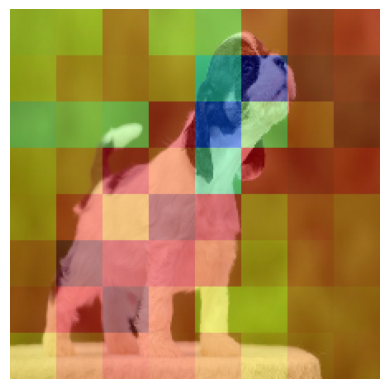

In [18]:
overlay = visualize_patch_map(img2, patch_map, patch_size=(28, 28))
plt.imshow(overlay)
plt.axis("off")